<a href="https://colab.research.google.com/github/Tuleen-Alshehri/final-project/blob/main/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase-3**

**First step** downloaded the libraries I needed.

In [ ]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('features_titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_ordinal,family_size,fare_per_person,Age_Pclass_interaction,Fare_log,Age_category,Fare_scaled
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True,1,1,7.2500,22.0,2.110213,adult,-0.820552
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,65.6344,False,False,False,3,1,65.6344,114.0,4.199221,adult,2.031623
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True,1,0,inf,26.0,2.188856,adult,-0.787578
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True,3,1,53.1000,105.0,3.990834,adult,1.419297
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True,1,0,inf,35.0,2.202765,adult,-0.781471


**step-2**  Histograms / KDE

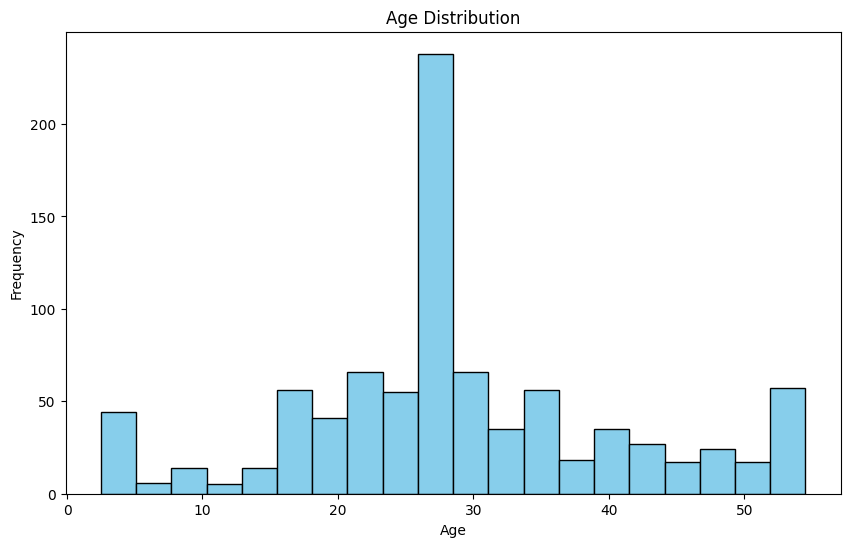

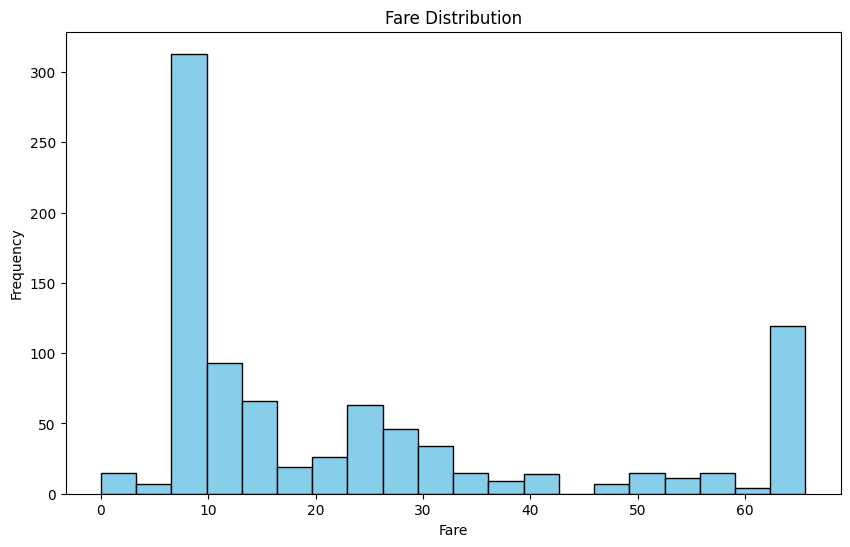

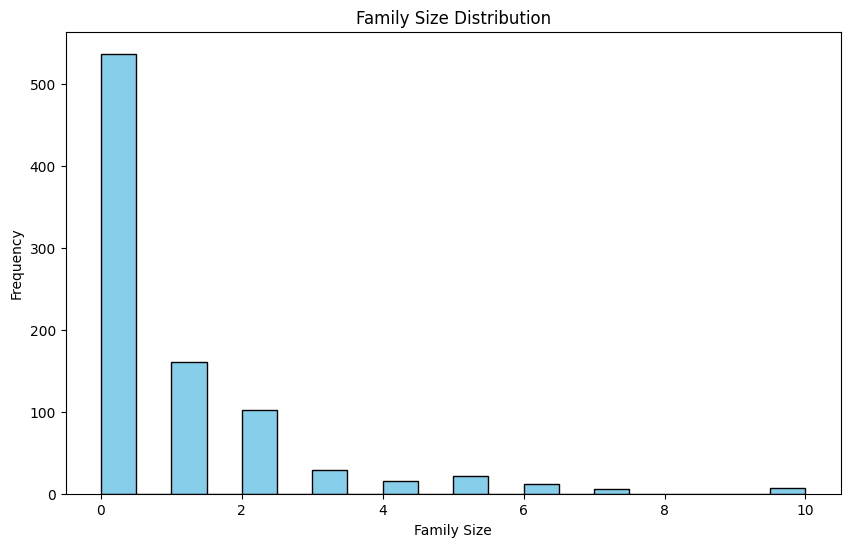

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Age Distribution")
plt.show()
#Age-The hist shows that most passengers are between 20 and 40 years old.

plt.figure(figsize=(10, 6))

plt.hist(df['Fare'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title("Fare Distribution")
plt.show()
#Fare-It appears that most ticket prices are low.

plt.figure(figsize=(10, 6))

plt.hist(df['family_size'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Family Size')
plt.ylabel('Frequency')
plt.title("Family Size Distribution")
plt.show()
#family_size-It appears that most passengers were traveling alone or with a small number of family members.

**step-3**  Grouped Boxplot

/tmp/ipykernel_9875/3815912847.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex_male', y='Survived', data=df, palette='pastel')


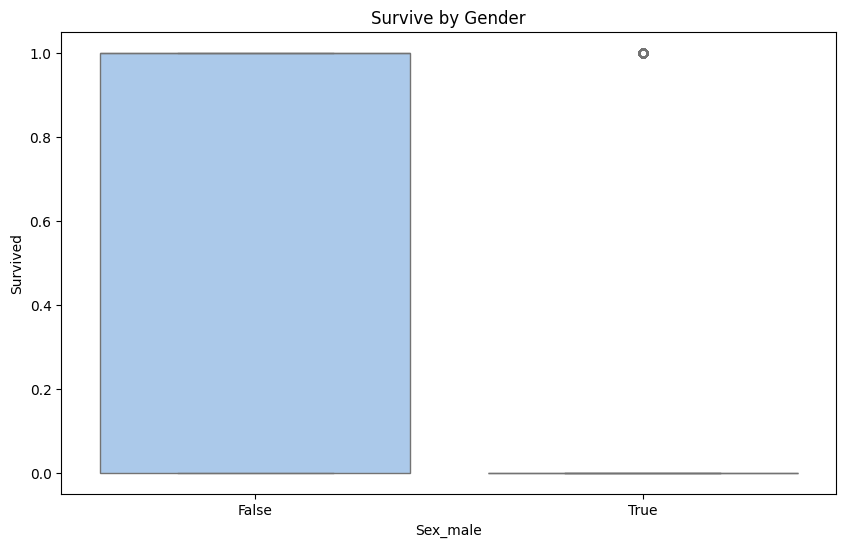

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sex_male', y='Survived', data=df, palette='pastel')
plt.title("Survive by Gender")
plt.show()
#The boxplot shows that the survival rate of females is higher than that of males indicating that sex was an important factor in survival.

**step-4**  Correlation Heatmap

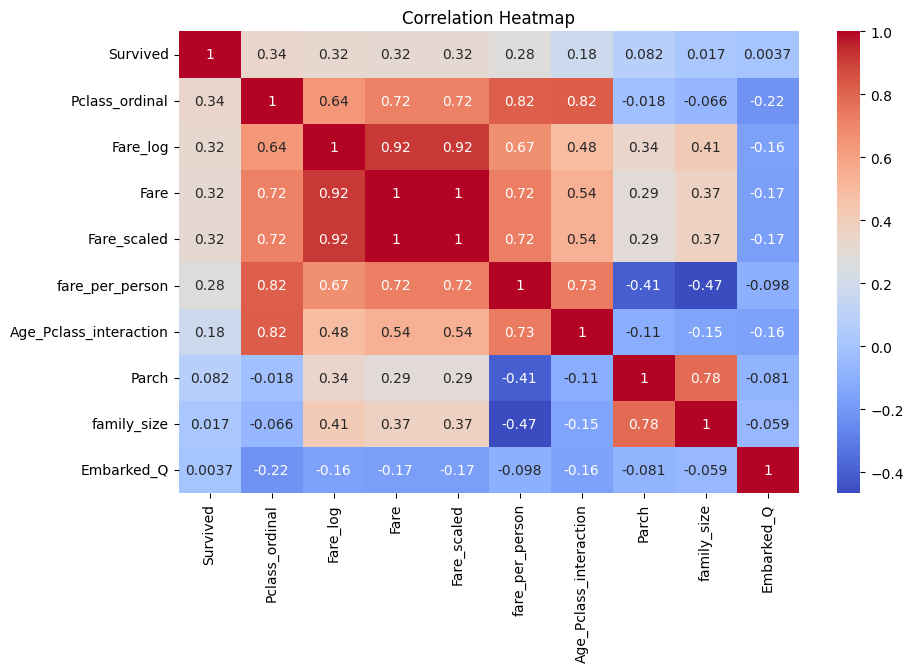

In [ ]:
corr = df.corr(numeric_only=True)
top_features = corr['Survived'].sort_values(ascending=False).head(10).index##
plt.figure(figsize=(10, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#The correlation map shows that gender grade and price are among the variables most strongly associated with survival.


**step-5**  Scatter Plot

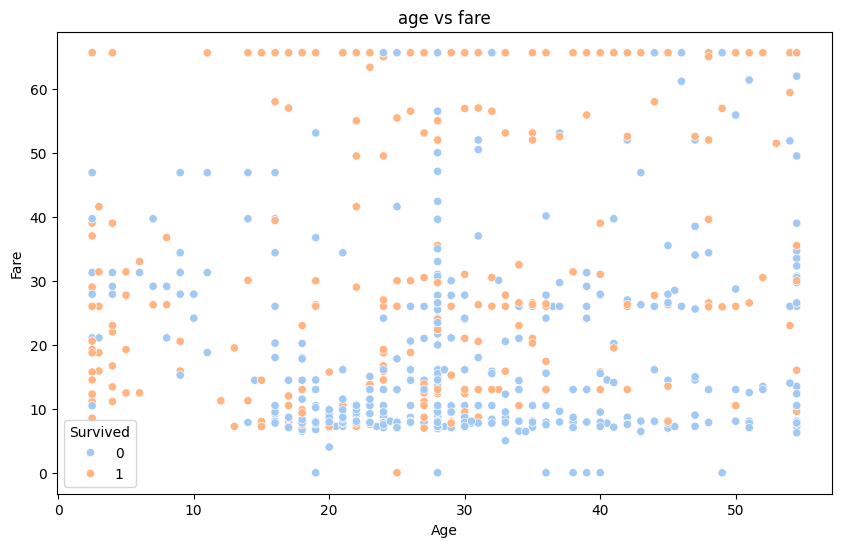

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, palette='pastel')
plt.title("age vs fare")
plt.show()
#The chart shows that passengers who paid higher prices had a greater chance of survival
# it also show that younger ages were more prevalent among the survivors.

**step-6**  Groupby Summary

Sex_male
False    0.742038
True     0.188908
Name: Survived, dtype: float64


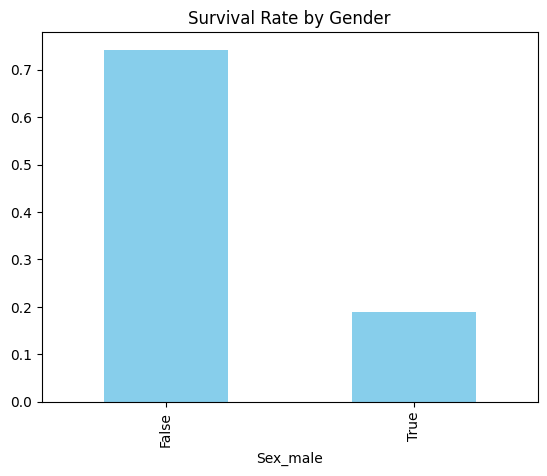

In [ ]:
group =  df.groupby('Sex_male')['Survived'].mean()
print(group)
group.plot(kind="bar",color="skyblue")
plt.title("Survival Rate by Gender")
plt.show()
#The graph shows that the survival rate of females is higher than that of males.

# **04_math.ipynb**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
target = df["Survived"].values
mean_target = np.mean(target)
print(mean_target)
#The average survival rate in the data represents

std_target = np.std(target)
print(std_target)
#It represents the extent to which survival values ​​are fragmented

#The average survival rate was 0.38, meaning that approximately 38% of passengers survived
#while the standard deviation indicates a variance between the number of survivors and the number of non-survivors.

0.3838383838383838
0.48631931786709987


**Standardize Column**

In [ ]:
x = df['Age'].values

mean = np.mean(x)
std = np.std(x)

z = (x - mean) / std

print(("equation"),z[:10])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(df[["Age"]])

print(("\n manually"),scaled[:5])

# The results show that the values ​​after manual standardization are very close to those of StandardScaler.
# confirming that the equation was applied correctly.

equation [-0.58343208  0.74268522 -0.25190275  0.49403823  0.49403823 -0.08613809
  2.06880252 -2.19963754 -0.16902042 -1.24649073]

 manually [[-0.58343208]
 [ 0.74268522]
 [-0.25190275]
 [ 0.49403823]
 [ 0.49403823]]


**Cosine Similarity**

In [ ]:
#This code calculates the cosine similarity between the passenger with the highest fare
#and the passenger with the lowest fare based on their Age and Fare features to measure how similar they are.
from numpy.linalg import norm

high_fare = df.loc[df["Fare"].idxmax()]
high = high_fare[["Age", "Fare"]].values

low_fare= df.loc[df["Fare"].idxmin()]
low = low_fare[["Age", "Fare"]].values

cosine = np.dot(high,low)/(norm(high)*norm(low))
print(cosine)

0.5010474972899414


**Estimate a probability**

In [ ]:
high_fare = df[df["Fare"] > 50]
prob = np.mean(high_fare["Survived"])
print("Probability:", prob)

Probability: 0.68125
